In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
## 3.2 Load Dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Shape data:", X.shape)

Shape data: (569, 30)


In [5]:
# 3.3 Standardisasi Data (WAJIB)
## PCA sangat sensitif terhadap skala.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
## 🔹 Bagian A – Menghitung Covariance Matrix
# 3.4 Covariance Matrix
cov_matrix = np.cov(X_scaled.T)
print("Shape Covariance Matrix:", cov_matrix.shape)


Shape Covariance Matrix: (30, 30)


In [7]:
## 🔹 Bagian B – Eigenvalue & Eigenvector Manual
# 3.5 Hitung Eigenvalue & Eigenvector
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n", eigenvalues[:5])
print("Eigenvectors shape:", eigenvectors.shape)


Eigenvalues:
 [13.30499079  5.7013746   2.82291016  1.98412752  1.65163324]
Eigenvectors shape: (30, 30)


In [8]:
## 🔹 Bagian C – PCA dengan sklearn
# 3.6 PCA Tanpa Reduksi (Semua Komponen)
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_


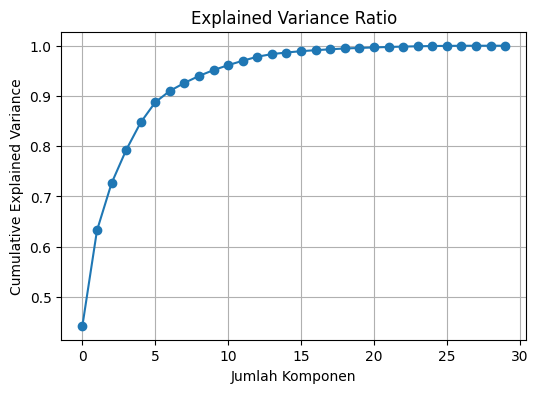

Komponen 80% : 5
Komponen 90% : 7
Komponen 95% : 10


In [12]:
## 3.7 Plot Explained Variance (Cumulative)
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel("Jumlah Komponen")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Ratio")
plt.grid()
plt.show()

pca_80 = PCA(n_components=0.80)
pca_80.fit(X_scaled)

print("Komponen 80% :", pca_80.n_components_)

pca_90 = PCA(n_components=0.90)
pca_90.fit(X_scaled)

print("Komponen 90% :", pca_90.n_components_)

pca_95 = PCA(n_components=0.95)
pca_95.fit(X_scaled)

print("Komponen 95% :", pca_95.n_components_)

In [13]:
## 🔹 Bagian D – Reduksi ke 2D
# 3.8 PCA 2 Komponen
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

print("Shape setelah PCA:", X_pca.shape)

Shape setelah PCA: (569, 2)


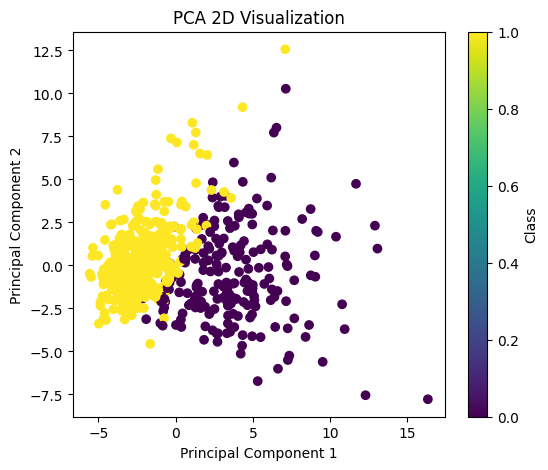

In [14]:
## 3.9 Visualisasi 2D
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Visualization")
plt.colorbar(label="Class")
plt.show()


In [16]:
## 🔹 Bagian E – Jumlah Komponen Optimal
# 3.10 Cari Jumlah Komponen untuk 90%
pca_90 = PCA(n_components=0.90)
X_pca_90 = pca_90.fit_transform(X_scaled)

print("Jumlah komponen untuk 90% variance:", pca_90.n_components_)

variance_table = pd.DataFrame({
    "Komponen": [
        "PC1",
        "PC2",
        "PC3"
    ],
    "Explained Variance": explained_variance[:3]
})

variance_table


Jumlah komponen untuk 90% variance: 7


,Komponen,Explained Variance
0,PC1,0.442720
1,PC2,0.189712
2,PC3,0.093932
